O serviço de vendas de carros usados Rusty Bargain está desenvolvendo um aplicativo para atrair novos clientes. Nesse aplicativo, você pode descobrir rapidamente o valor de mercado do seu carro. Você tem acesso a dados históricos: especificações técnicas, versões de acabamento e preços. Você precisa construir o modelo para determinar o valor. 

Rusty Bargain está interessado em:

- a qualidade da predição;
- a velocidade da predição;
- o tempo necessário para o treinamento

## Preparação de Dados

In [2]:
# Importação de Bibliotecas

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from lightgbm import LGBMRegressor

In [4]:
# Carregamento de Dados

df = pd.read_csv('car_data.csv')
df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17


In [5]:
# Pré-processamento de Dados

# Remoção de colunas inúties
df = df.drop([
    'DateCrawled', 'DateCreated', 'LastSeen',
    'PostalCode', 'NumberOfPictures'
], axis=1)

In [6]:
# Tratamento de Valores Ausentes
df = df.fillna('unknown')


In [7]:
# Preparação de Dados para Treinamento

# Separação de features e target
X = df.drop('Price', axis=1)
y = df['Price']

# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# Divisão de Dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

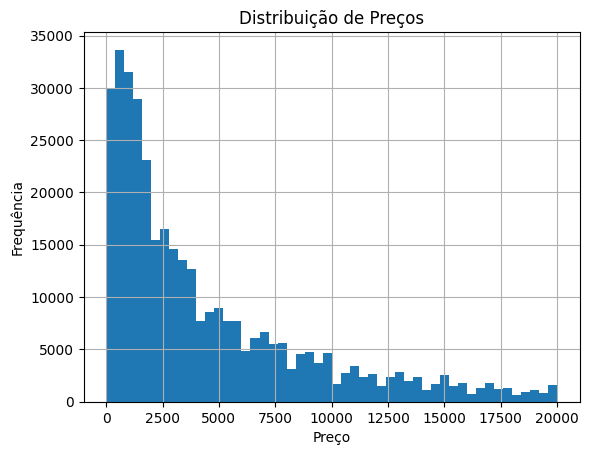

In [8]:
# Análise exploratória de Dados

# Distribuição de preços
plt.figure()
df['Price'].hist(bins=50)
plt.title('Distribuição de Preços')
plt.xlabel('Preço')
plt.ylabel('Frequência')
plt.show()

<Figure size 640x480 with 0 Axes>

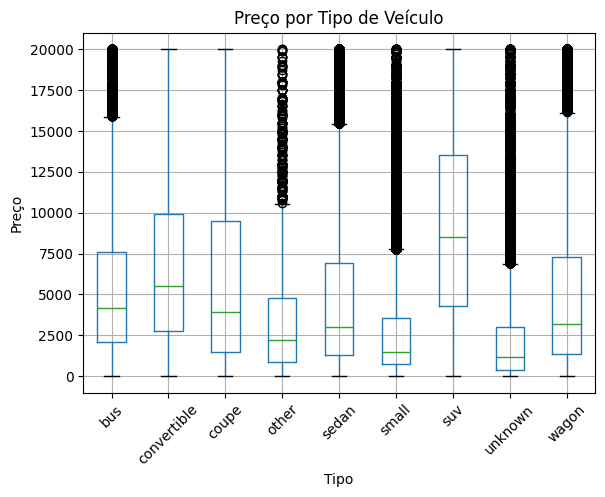

In [9]:
# Preço por veículos

plt.figure()
df.boxplot(column='Price', by='VehicleType', rot=45)
plt.title('Preço por Tipo de Veículo')
plt.suptitle('')
plt.xlabel('Tipo')
plt.ylabel('Preço')
plt.show()

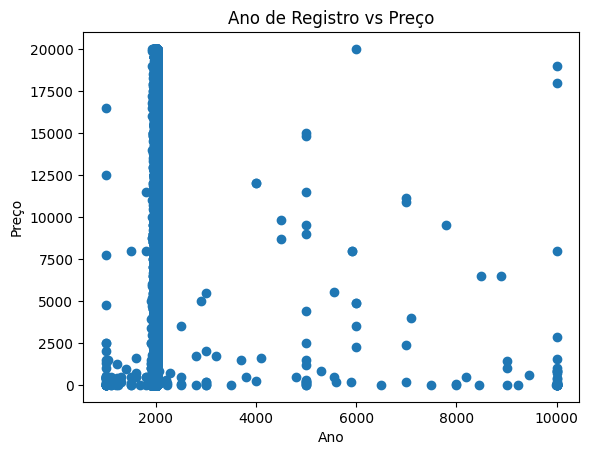

In [10]:
plt.figure()
plt.scatter(df['RegistrationYear'], df['Price'])
plt.title('Ano de Registro vs Preço')
plt.xlabel('Ano')
plt.ylabel('Preço')
plt.show()

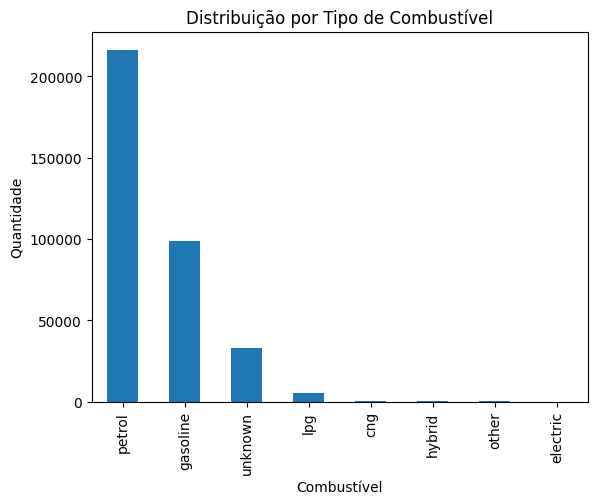

In [11]:
# Tipo de combustível

plt.figure()
df['FuelType'].value_counts().plot(kind='bar')
plt.title('Distribuição por Tipo de Combustível')
plt.xlabel('Combustível')
plt.ylabel('Quantidade')
plt.show()

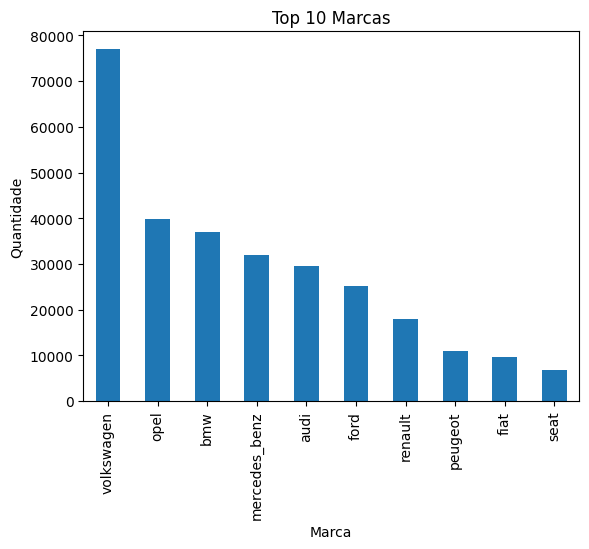

In [12]:
# marcas mais populares

plt.figure()
df['Brand'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Marcas')
plt.xlabel('Marca')
plt.ylabel('Quantidade')
plt.show()

## Treinamento do modelo

In [16]:
# Função de Avaliação

def evaluate_model(model, X_train, X_test, y_train, y_test):
    import time
    import numpy as np
    from sklearn.metrics import mean_squared_error
    
    start = time.time()
    
    model.fit(X_train, y_train)
    
    train_time = time.time() - start
    
    pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    
    return rmse, train_time

In [17]:
# Modelos

# Regressão Linear
lr = LinearRegression()

rmse_lr, time_lr = evaluate_model(lr, X_train, X_test, y_train, y_test)

print("Linear Regression RMSE:", rmse_lr)
print("Tempo:", time_lr)

Linear Regression RMSE: 3214.6073978423383
Tempo: 8.636149883270264


In [18]:
# Árvore de Decisão
dt = DecisionTreeRegressor(max_depth=10, random_state=42)

rmse_dt, time_dt = evaluate_model(dt, X_train, X_test, y_train, y_test)

print("Decision Tree RMSE:", rmse_dt)

Decision Tree RMSE: 2149.291731935051


In [19]:
# Floresta Aleatória
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rmse_rf, time_rf = evaluate_model(rf, X_train, X_test, y_train, y_test)

print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 1842.269713301299


In [20]:
# LightGBM
lgbm = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=10,
    random_state=42
)

rmse_lgbm, time_lgbm = evaluate_model(lgbm, X_train, X_test, y_train, y_test)

print("LightGBM RMSE:", rmse_lgbm)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024679 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 969
[LightGBM] [Info] Number of data points in the train set: 283495, number of used features: 297
[LightGBM] [Info] Start training from score 4406.829461
LightGBM RMSE: 1862.3436507690385


In [21]:
for depth in [5, 10, 15]:
    model = RandomForestRegressor(max_depth=depth, n_estimators=50)
    rmse, _ = evaluate_model(model, X_train, X_test, y_train, y_test)
    print(f"Depth {depth}: RMSE = {rmse}")

Depth 5: RMSE = 2531.997807231866
Depth 10: RMSE = 2053.7900915788086
Depth 15: RMSE = 1844.2767150758125


## Análise do modelo

O modelo LightGBM apresentou o melhor desempenho em termos de RMSE, porém com maior custo computacional. A regressão linear serviu como baseline e validou que modelos mais complexos realmente melhoram a performance.

# Checklist

Digite 'x' para verificar. Em seguida, pressione Shift + Enter.

- [x]  O Jupyter Notebook está aberto
- [x]  O código está livre de erros
- [x]  As células com o código foram organizadas em ordem de execução
- [x]  Os dados foram baixados e preparados
- [x]  Os modelos foram treinados
- [x]  A análise de velocidade e qualidade dos modelos foi realizada